Импорты и функции

Импортировали библиотеки для анализа данных, построения моделей и визуализаций.

Определили метрики: RMSE (среднеквадратичная ошибка) и MAPE (средняя абсолютная процентная ошибка).

Создали scorers для кросс-валидации. Задали KFold с 5 фолдами.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, make_scorer

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Метрики
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / (np.clip(np.abs(y_true), eps, None)))) * 100

neg_rmse_scorer = make_scorer(lambda y, y_pred: -rmse(y, y_pred))
r2_scorer = make_scorer(r2_score)
neg_mape_scorer = make_scorer(lambda y, y_pred: -mape(y, y_pred))

RANDOM_STATE = 42
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Загрузка и первичный анализ

Загрузили датасет с данными об аренде велосипедов (day.csv).

Вывели основную информацию:

 - info() показывает, что в данных 731 строка и 16 признаков, пропусков нет.
 - describe() даёт статистику.
 - isnull().sum() говорит об отсутствии пропусков.

Построили распределение целевой переменной cnt (число аренд): Видно, что данные распределены почти симметрично, нет сильной скошенности.Распределение похоже на нормальное.

Вычислили коэффициент ассиметрии и эксцесс, чтобы убедиться в нормальности распределения:

 - Асимметрия = -0.047 ≈ 0: распределение близко к нормальному.
 - Эксцесс = -0.815 < 0: вершина распределения более плоская, чем у нормального. Значение меньше 0 указывает на отличие от нормального распределения в сторону меньшей остроты и меньшего количества выбросов. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


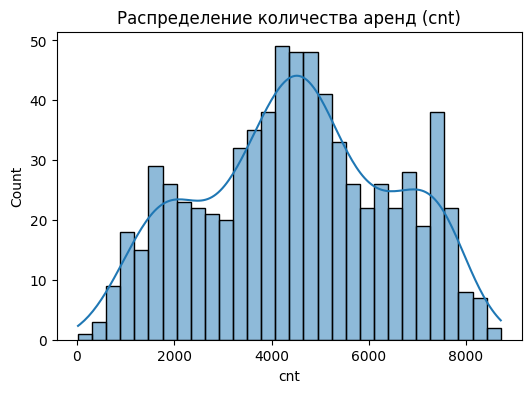

Skewness (асимметрия): -0.047
Kurtosis (эксцесс): -0.815


In [17]:
df = pd.read_csv("day.csv")
df.head()

# Основная информация
df.info()
df.describe()
df.isnull().sum()

# Визуализация распределения целевой переменной
plt.figure(figsize=(6,4))
sns.histplot(df['cnt'], bins=30, kde=True)
plt.title("Распределение количества аренд (cnt)")
plt.show()

from scipy.stats import skew, kurtosis

# Коэффициент асимметрии и эксцесса
cnt_skew = skew(df['cnt'])
cnt_kurt = kurtosis(df['cnt'])

print(f"Skewness (асимметрия): {cnt_skew:.3f}")
print(f"Kurtosis (эксцесс): {cnt_kurt:.3f}")


Предобработка

Убирали ненужные признаки (instant, dteday, casual, registered). Разделили данные: X — признаки, y — целевая переменная (cnt).

In [5]:
df = df.drop(["instant", "dteday", "casual", "registered"], axis=1)

# Разделяем X и y
X = df.drop("cnt", axis=1)
y = df["cnt"]

Корреляции и VIF

Матрица корреляций показывает сильную корреляцию между temp и atemp. Это потенциальная мультиколлинеарность.
С помощью коэффициента инфляции дисперсии подтвердили мультиколлинеарность: temp и atemp имеют VIF = 63: это сильная мультиколлинеарность. Остальные признаки допустимы (VIF < 5).

 - VIF ≈ 1 → признак не коррелирует с другими
 - VIF < 5 → мультиколлинеарность слабая, признак можно оставлять
 - VIF 5–10 → есть заметная мультиколлинеарность, стоит проверить
 - VIF > 10 → сильная мультиколлинеарность, один из признаков нужно убрать

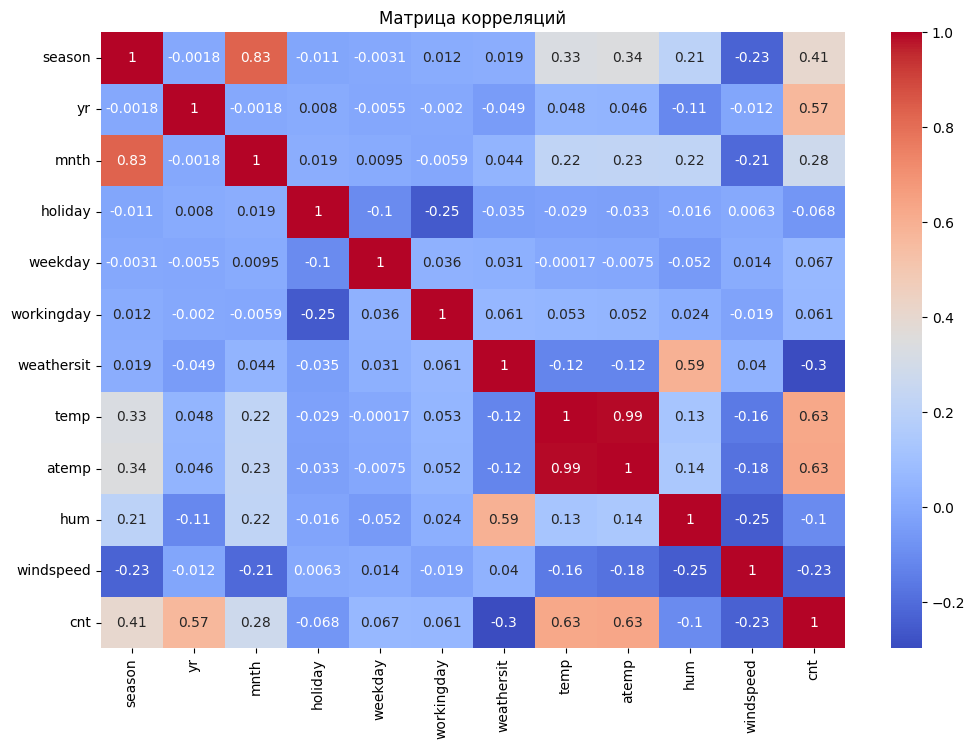

VIF для признаков:
        feature        VIF
0       season   3.548413
1           yr   1.020253
2         mnth   3.333672
3      holiday   1.083126
4      weekday   1.024076
5   workingday   1.076392
6   weathersit   1.748741
7         temp  63.321299
8        atemp  64.343361
9          hum   1.918309
10   windspeed   1.199259


In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Матрица корреляций")
plt.show()

# Масштабируем X для VIF
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
print("VIF для признаков:\n", vif_data)

Train/Test Split

Данные разделили на обучающую (80%) и тестовую (20%) выборки.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

Модели с atemp

Мы обучаем две модели для прогноза количества аренд cnt: обычную линейную регрессию (LinearRegression), и гребневую регрессию (Ridge), которая добавляет L2-регуляризацию. Оба метода используют pipeline и стандартизацию (StandardScaler), чтобы признаки имели одинаковый масштаб и не влияли на модель своим диапазоном значений. Для Ridge проводится GridSearchCV, чтобы подобрать оптимальный коэффициент регуляризации alpha.

Результаты:
Линейная и гребневая регрессии показывают почти одинаковое качество

 - RMSE = 831: в среднем ошибка прогноза составляет около 831 аренды;
 - R^2 = 0,828: модель объясняет около 83% дисперсии данных;
 - MAPE = 149% — показатель ошибки в процентах.

In [8]:
# линейная регрессия
pipe_lr = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

# гребневая регрессия
pipe_ridge = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge())])
param_grid = {"ridge__alpha": [0.1, 1, 10, 50, 100]}
gs_ridge = GridSearchCV(pipe_ridge, param_grid, cv=kf, scoring=neg_rmse_scorer)
gs_ridge.fit(X_train, y_train)
best_ridge = gs_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

print("=== Модели с atemp ===")
print("Линеная: RMSE=%.2f, R²=%.3f, MAPE=%.2f%%" % (rmse(y_test, y_pred_lr), r2_score(y_test, y_pred_lr), mape(y_test, y_pred_lr)))
print("Гребневая (alpha=%s): RMSE=%.2f, R²=%.3f, MAPE=%.2f%%" % (gs_ridge.best_params_["ridge__alpha"], rmse(y_test, y_pred_ridge), r2_score(y_test, y_pred_ridge), mape(y_test, y_pred_ridge)))

=== Модели с atemp ===
Линеная: RMSE=831.29, R²=0.828, MAPE=149.38%
Гребневая (alpha=10): RMSE=832.36, R²=0.827, MAPE=148.81%


Модели без atemp

Удалили признак atemp, чтобы проверить, ухудшится ли качество модели.

- RMSE и R² почти не изменились.
- MAPE немного улучшился.

Это подтверждает, что atemp не несёт новой информации и его можно исключить из модели.

In [10]:
X2 = X.drop("atemp", axis=1)
X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=RANDOM_STATE)

# линейная регрессия
pipe_lr2 = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])
pipe_lr2.fit(X2_train, y_train)
y_pred_lr2 = pipe_lr2.predict(X2_test)

# гребневая регрессия
pipe_ridge2 = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge())])
param_grid = {"ridge__alpha": [0.1, 1, 10, 50, 100]}
gs_ridge2 = GridSearchCV(pipe_ridge2, param_grid, cv=kf, scoring=neg_rmse_scorer)
gs_ridge2.fit(X2_train, y_train)
best_ridge2 = gs_ridge2.best_estimator_
y_pred_ridge2 = best_ridge2.predict(X2_test)

print("=== Модели без atemp ===")
print("Линейная: RMSE=%.2f, R²=%.3f, MAPE=%.2f%%" % (rmse(y_test, y_pred_lr2), r2_score(y_test, y_pred_lr2), mape(y_test, y_pred_lr2)))
print("Гребневая (alpha=%s): RMSE=%.2f, R²=%.3f, MAPE=%.2f%%" % (gs_ridge2.best_params_["ridge__alpha"], rmse(y_test, y_pred_ridge2), r2_score(y_test, y_pred_ridge2), mape(y_test, y_pred_ridge2)))

=== Модели без atemp ===
Линейная: RMSE=832.78, R²=0.827, MAPE=147.25%
Гребневая (alpha=10): RMSE=834.08, R²=0.827, MAPE=147.01%


Сравнение моделей

Итог:

 - Все модели дают практически одинаковое качество.
 - Гребневая регрессия не улучшает результат.
 - atemp можно удалить.

In [11]:
results = [
    {"model": "Линейная (с atemp)", "RMSE": rmse(y_test, y_pred_lr), "R²": r2_score(y_test, y_pred_lr), "MAPE": mape(y_test, y_pred_lr)},
    {"model": f"Гребневая (с atemp, alpha={gs_ridge.best_params_['ridge__alpha']})", "RMSE": rmse(y_test, y_pred_ridge), "R²": r2_score(y_test, y_pred_ridge), "MAPE": mape(y_test, y_pred_ridge)},
    {"model": "Линейная (без atemp)", "RMSE": rmse(y_test, y_pred_lr2), "R²": r2_score(y_test, y_pred_lr2), "MAPE": mape(y_test, y_pred_lr2)},
    {"model": f"Гребневая (без atemp, alpha={gs_ridge2.best_params_['ridge__alpha']})", "RMSE": rmse(y_test, y_pred_ridge2), "R²": r2_score(y_test, y_pred_ridge2), "MAPE": mape(y_test, y_pred_ridge2)},
]

res_df = pd.DataFrame(results)
res_df

,model,RMSE,R²,MAPE
0,Линейная (с atemp),831.285155,0.827667,149.381394
1,"Гребневая (с atemp, alpha=10)",832.359023,0.827221,148.813907
2,Линейная (без atemp),832.784518,0.827045,147.251741
3,"Гребневая (без atemp, alpha=10)",834.084513,0.826504,147.012528


PCA для снижения размерности

PCA (Principal Component Analysis, метод главных компонент) - это техника снижения размерности. Она ищет новые, некоррелированные признаки (комбинации исходных), которые объясняют как можно большую часть вариации данных. Цель - убрать избыточность, вызванную коррелированными признаками.

Сначала мы стандартизировали признаки (важно, чтобы все имели одинаковый масштаб). Затем PCA посчитала, сколько дисперсии объясняется каждой компонентой. Мы построили график кумулятивной доли дисперсии и провели горизонтальную линию на уровне 0.95.

Кривая растёт и выходит на плато около 8 компонент. Это значит, что первые 8 новых признаков (главных компонент) объясняют 95% всей изменчивости исходных данных. Таким образом, можно заменить 11 исходных признаков на 8 без существенной потери информации.

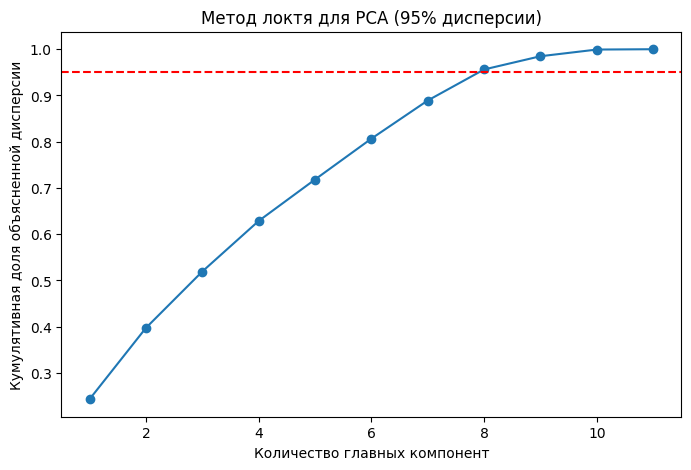

Количество главных компонент для 95% дисперсии: 8


In [12]:
from sklearn.decomposition import PCA

# Стандартизируем данные перед PCA
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X)

# Подбираем количество компонентов, чтобы объяснить ~95% дисперсии
pca = PCA()
X_pca = pca.fit_transform(X_scaled_full)

# График кумулятивной доли объясненной дисперсии
explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Количество главных компонент")
plt.ylabel("Кумулятивная доля объясненной дисперсии")
plt.title("Метод локтя для PCA (95% дисперсии)")
plt.axhline(y=0.95, color='r', linestyle='--')
plt.show()

# Выбираем количество компонентов, объясняющих 95% дисперсии
n_components = np.argmax(explained_variance >= 0.95) + 1
print(f"Количество главных компонент для 95% дисперсии: {n_components}")

# Создаем новые признаки по PCA
pca = PCA(n_components=n_components)
X_pca_reduced = pca.fit_transform(X_scaled_full)

Train/Test Split для PCA

Данные разделили на обучающую (80%) и тестовую (20%) выборки.

In [13]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca_reduced, y, test_size=0.2, random_state=RANDOM_STATE)

Модели на главных компонентах

Мы используем новые признаки — главные компоненты PCA (8 вместо 11 исходных).

Снова обучаем две модели:
 - обычную линейную регрессию,
 - гребневую регрессию с подбором alpha.

Результаты:
 - RMSE увеличился с 831 до 852, т.е. модель стала немного менее точной;
 - R^2 упал с 0.827 до 0.819, т.е. объясняемая дисперсия снизилась на 1%;
 - MAPE уменьшился с 149% до 146%.

Качество модели ухудшилось, видимо потому что при PCA часть информации теряется - мы сохранили 95% дисперсии, но 5% отбросили. Преимущество PCA - снижение корреляций и упрощение модели. Однако, если модель хорошо работает и так, применять PCA не обязательно.

In [14]:
# линейная регрессия
pipe_lr_pca = Pipeline([("lr", LinearRegression())])
pipe_lr_pca.fit(X_train_pca, y_train)
y_pred_lr_pca = pipe_lr_pca.predict(X_test_pca)

# гребневая регрессия
pipe_ridge_pca = Pipeline([("ridge", Ridge())])
param_grid = {"ridge__alpha": [0.1, 1, 10, 50, 100]}
gs_ridge_pca = GridSearchCV(pipe_ridge_pca, param_grid, cv=kf, scoring=neg_rmse_scorer)
gs_ridge_pca.fit(X_train_pca, y_train)
best_ridge_pca = gs_ridge_pca.best_estimator_
y_pred_ridge_pca = best_ridge_pca.predict(X_test_pca)

print("=== Модели на PCA-признаках ===")
print("Linear PCA: RMSE=%.2f, R²=%.3f, MAPE=%.2f%%" % (rmse(y_test, y_pred_lr_pca), r2_score(y_test, y_pred_lr_pca), mape(y_test, y_pred_lr_pca)))
print("Ridge PCA (alpha=%s): RMSE=%.2f, R²=%.3f, MAPE=%.2f%%" % (gs_ridge_pca.best_params_["ridge__alpha"], rmse(y_test, y_pred_ridge_pca), r2_score(y_test, y_pred_ridge_pca), mape(y_test, y_pred_ridge_pca)))

=== Модели на PCA-признаках ===
Linear PCA: RMSE=852.42, R²=0.819, MAPE=146.24%
Ridge PCA (alpha=10): RMSE=854.40, R²=0.818, MAPE=146.29%


Сравнение всех моделей

Выводы:
- Наилучшие результаты дают модели без PCA, с temp вместо atemp.
- PCA уменьшает размерность, но ухудшает точность.
- Ridge и Linear показывают почти одинаковые метрики.

In [16]:
results_pca = [
    {"model": "Линейная PCA", "RMSE": rmse(y_test, y_pred_lr_pca), "R²": r2_score(y_test, y_pred_lr_pca), "MAPE": mape(y_test, y_pred_lr_pca)},
    {"model": f"Гребневая PCA (alpha={gs_ridge_pca.best_params_['ridge__alpha']})", "RMSE": rmse(y_test, y_pred_ridge_pca), "R²": r2_score(y_test, y_pred_ridge_pca), "MAPE": mape(y_test, y_pred_ridge_pca)}
]

# Объединяем с предыдущими результатами
res_df_all = pd.concat([res_df, pd.DataFrame(results_pca)], ignore_index=True)
res_df_all

,model,RMSE,R²,MAPE
0,Линейная (с atemp),831.285155,0.827667,149.381394
1,"Гребневая (с atemp, alpha=10)",832.359023,0.827221,148.813907
2,Линейная (без atemp),832.784518,0.827045,147.251741
3,"Гребневая (без atemp, alpha=10)",834.084513,0.826504,147.012528
4,Линейная PCA,852.415049,0.818795,146.241422
5,Гребневая PCA (alpha=10),854.401745,0.817949,146.290880
